# Assignment — Logistic Regression on `penguins.csv`

**Question:** given a penguin's measurements, is it male or female?

Target: `sex` &nbsp;·&nbsp; File: `penguins.csv`

Use only the numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g`.

**Keep this notebook.** Next class we will come back to the model you build here and
measure it properly.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## 1. Look at the data

> **Flow:** Shape, columns, missing values.

Run `.info()`. Which columns have missing values, and how many?

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


How many male and how many female? Use `sns.countplot`.

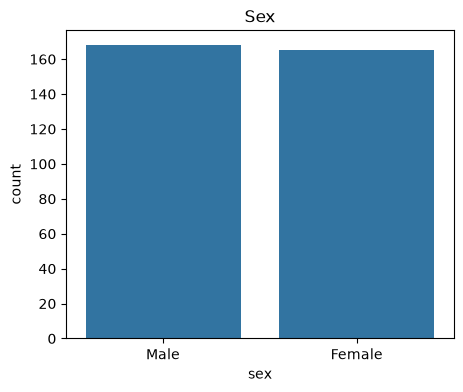

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='sex')
plt.title("Sex")
plt.show()

*Counts:* &nbsp;&nbsp; *Are the two classes roughly equal, or is one much bigger?*

#male is slightly bigger

Now compare the two groups on one measurement. Use `sns.barplot` with `x='sex'` and
`y='body_mass_g'`.

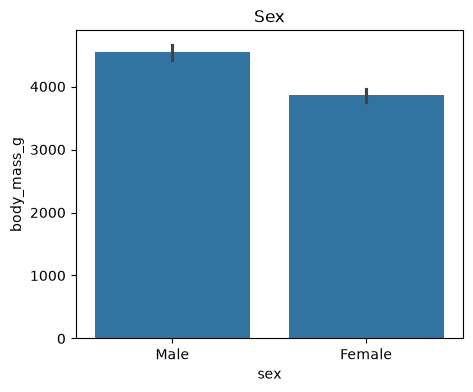

In [11]:
plt.figure(figsize=(5,4))
sns.barplot(data=df, x='sex',y='body_mass_g')
plt.title("Sex")
plt.show()


**Q.** Looking at that plot, does `body_mass_g` look useful for telling males and females
apart? One line.

#yes,higher body mass indicate male whereas lower female

---
## 2. Clean

> **Flow:** The target cannot be guessed. Rows missing it have to go.

`sex` is what we are trying to predict, so we cannot fill it in. Keep the four numeric
columns plus `sex`, then `dropna()`.

In [12]:
columns_to_keep = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
df = df[columns_to_keep].dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   sex                333 non-null    str    
dtypes: float64(4), str(1)
memory usage: 15.6 KB


*How many rows are left?*

# 333 rows

The target is text — `Male` and `Female`. Map it to numbers:
`{'Female': 0, 'Male': 1}`.

In [13]:
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})

---
## 3. Features and target

In [14]:
x = df.drop(columns='sex')
y =  df['sex']

---
## 4. Split

> **Flow:** `test_size=0.2`, `random_state=42`, `stratify=y`.

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

**Q.** Why do we use `stratify=y` here? One line.

# It keeps the same Male/Female proportion in both the training and test sets.

---
## 5. Train the model

> **Flow:** Two lines, same as always.

Train `LogisticRegression(max_iter=1000)` and predict on the test set.

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(y_pred)


[1 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0
 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 1]


**Q.** What does `max_iter=1000` do? One line.

---
## 6. Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8656716417910447
